In [33]:
from bertologist.data.Datasets import (
    ClusteredWordsDataset,
)

import pandas as pd
import nltk
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("datasets/training_dataset_light.csv")
dataset = ClusteredWordsDataset(df)

Loading sentences into dataframe: 100%|██████████| 17858/17858 [00:11<00:00, 1543.90it/s]


### Lets take a look at the shape of our data

In [3]:
dataset.data.shape
print(f"The dataset contains {dataset.data.shape[0]} different sentences.")
print(f"The dataset contains top {dataset.data.shape[1]} words with highest salience score.")
print(f"The dataset vocabulary size is {dataset.data.shape[2]}.")

The dataset contains 17858 different sentences.
The dataset contains top 10 words with highest salience score.
The dataset vocabulary size is 12076.


### Now we can study the dataframe more in depth

In [4]:
df.head()

,sentence,word,attention,cluster_label,sentence_index,salience_value,salience_score
0,"5 dead, 8 injured in fiery los angeles crash a...",red,NaN,0,0,0.051622,attention
1,"5 dead, 8 injured in fiery los angeles crash a...",after,NaN,0,0,0.035023,attention
2,"5 dead, 8 injured in fiery los angeles crash a...",[CLS],NaN,0,0,0.033418,attention
3,"5 dead, 8 injured in fiery los angeles crash a...",runs,NaN,0,0,0.033182,attention
4,"5 dead, 8 injured in fiery los angeles crash a...",speeding,NaN,0,0,0.030060,attention


Text(0.5, 0.98, 'Frequency and cumulative frequency of words. This time without stopwords')

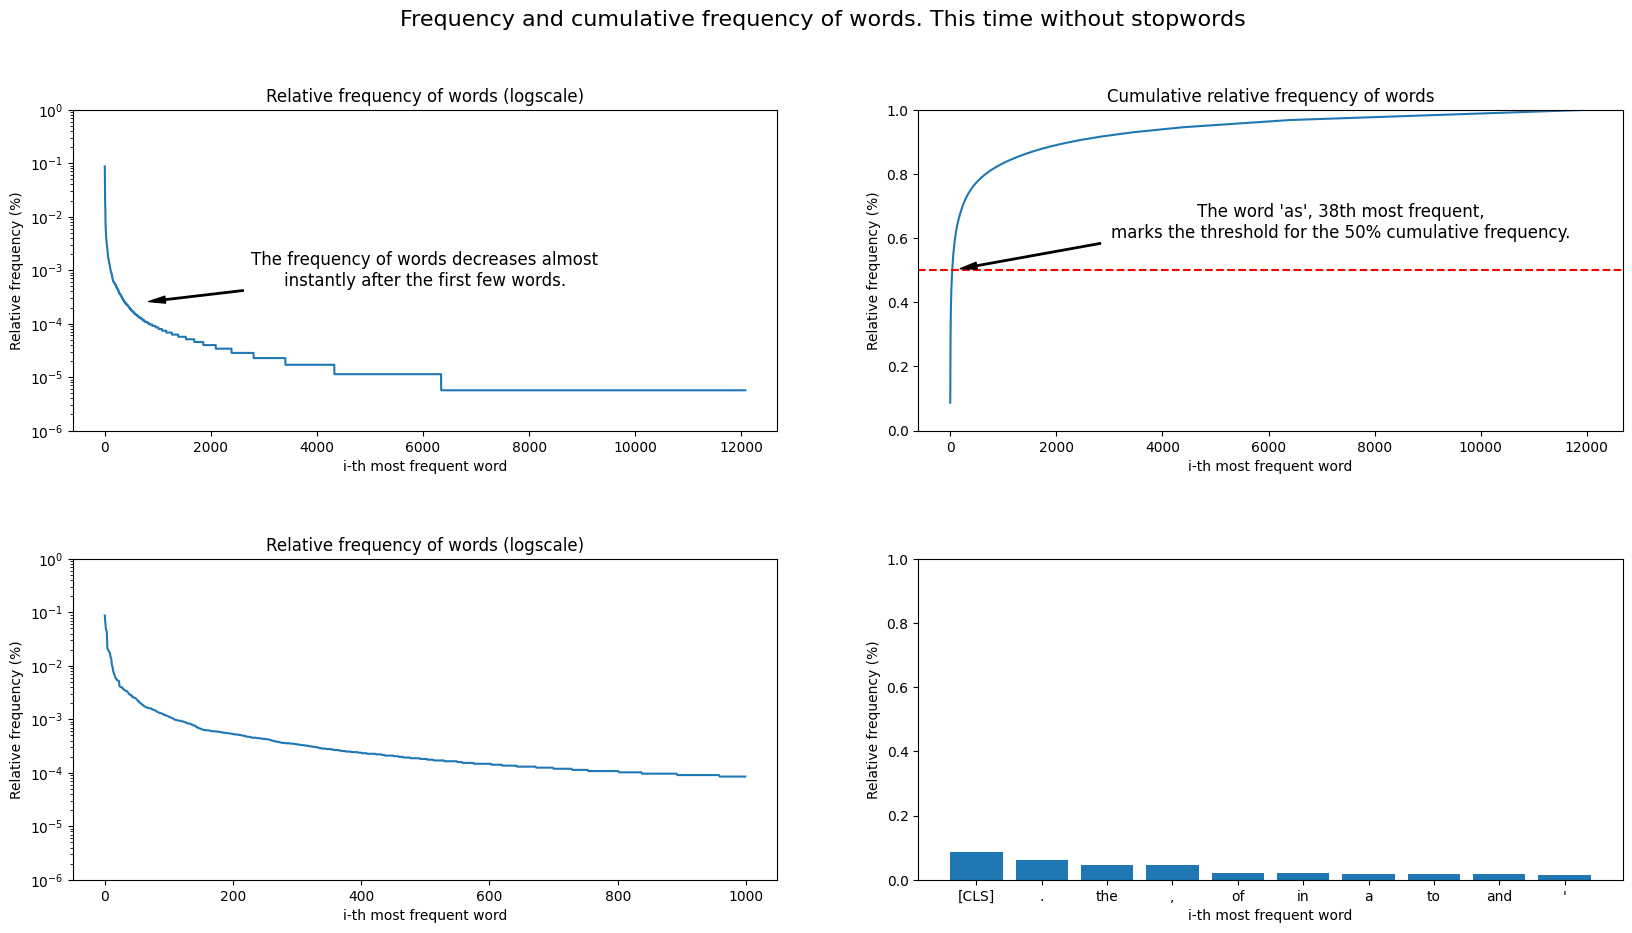

In [169]:
words = df["word"]

# sort by frequency
counts = words.value_counts()
counts = counts.sort_values(ascending=False)

# plot values in a line
frequency = counts.values
relative_frequency = frequency / frequency.sum()

# find the position of the first value with the cummulative frequency > 0.5
half_x = (relative_frequency.cumsum() > 0.5).argmax()
word_half_x = counts.index[half_x]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4)
for i, row in enumerate(ax):
    for j, col in enumerate(row):
        # defaults
        col.set_ylim(0, 1)
        col.set_xlabel("i-th most frequent word")
        col.set_ylabel("Relative frequency (%)")
        if i == 0:
            if j == 0:
                col.set_yscale("log")
                col.plot(relative_frequency)
                # change ylim to show the plot better
                col.set_ylim(1e-6, 1)
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
                col.annotate(
                    "The frequency of words decreases almost\ninstantly after the first few words.",
                    xy=(0.1, 0.4),
                    xytext=(0.5, 0.5),
                    # the text 
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                    xycoords="axes fraction",
                )
            else:
                col.plot(relative_frequency.cumsum())
                col.set_title("Cumulative relative frequency of words")
                # show the x-value where the y value is 0.5
                col.axhline(y=0.5, color="r", linestyle="--")
                col.annotate(
                    f"The word '{word_half_x}', {half_x}th most frequent,\nmarks the threshold for the 50% cumulative frequency.",
                    xycoords="data",
                    textcoords="axes fraction",
                    xy=(half_x, 0.5),
                    xytext=(0.6, 0.65),
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                )
        else:
            #col.set_xticks(range(1000))
            #col.set_xticklabels(counts.index[:1000])
            if j == 0:
                col.set_yscale("log")
                col.plot(relative_frequency[:1000])
                # change ylim to show the plot better
                col.set_ylim(1e-6, 1)
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
            else:
                # show bar chart of the top 10 words
                col.bar(counts.index[:10], relative_frequency[:10])

# Title
fig.suptitle("Frequency and cumulative frequency of words. This time without stopwords", fontsize=16)

    

# Let's repeat the experiment without stopwords

In [133]:
# Remove stopwords and [CLS]
nltk.download("stopwords")
from nltk.corpus import stopwords

stop_words = stopwords.words("english")
stop_words.append("[CLS]")
stop_words.append("[SEP]")
# add punctuation
stop_words.extend(["<",">","'", "/", r'"', "-", ".", ",", "!", "?", ":", ";", "(", ")", "[", "]", "{", "}", "br"])
# filter rows with stopwords
df_nonstop = df[~df["word"].isin(stop_words)]
df_nonstop.head()

[nltk_data] Downloading package stopwords to /home/lanver/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentence,word,attention,cluster_label,sentence_index,salience_value,salience_score
0,"5 dead, 8 injured in fiery los angeles crash a...",red,NaN,0,0,0.051622,attention
3,"5 dead, 8 injured in fiery los angeles crash a...",runs,NaN,0,0,0.033182,attention
4,"5 dead, 8 injured in fiery los angeles crash a...",speeding,NaN,0,0,0.030060,attention
5,"5 dead, 8 injured in fiery los angeles crash a...",car,NaN,0,0,0.027096,attention
6,"5 dead, 8 injured in fiery los angeles crash a...",crash,NaN,0,0,0.020186,attention


Text(0.5, 0.98, 'Frequency and cumulative frequency of words. This time without stopwords')

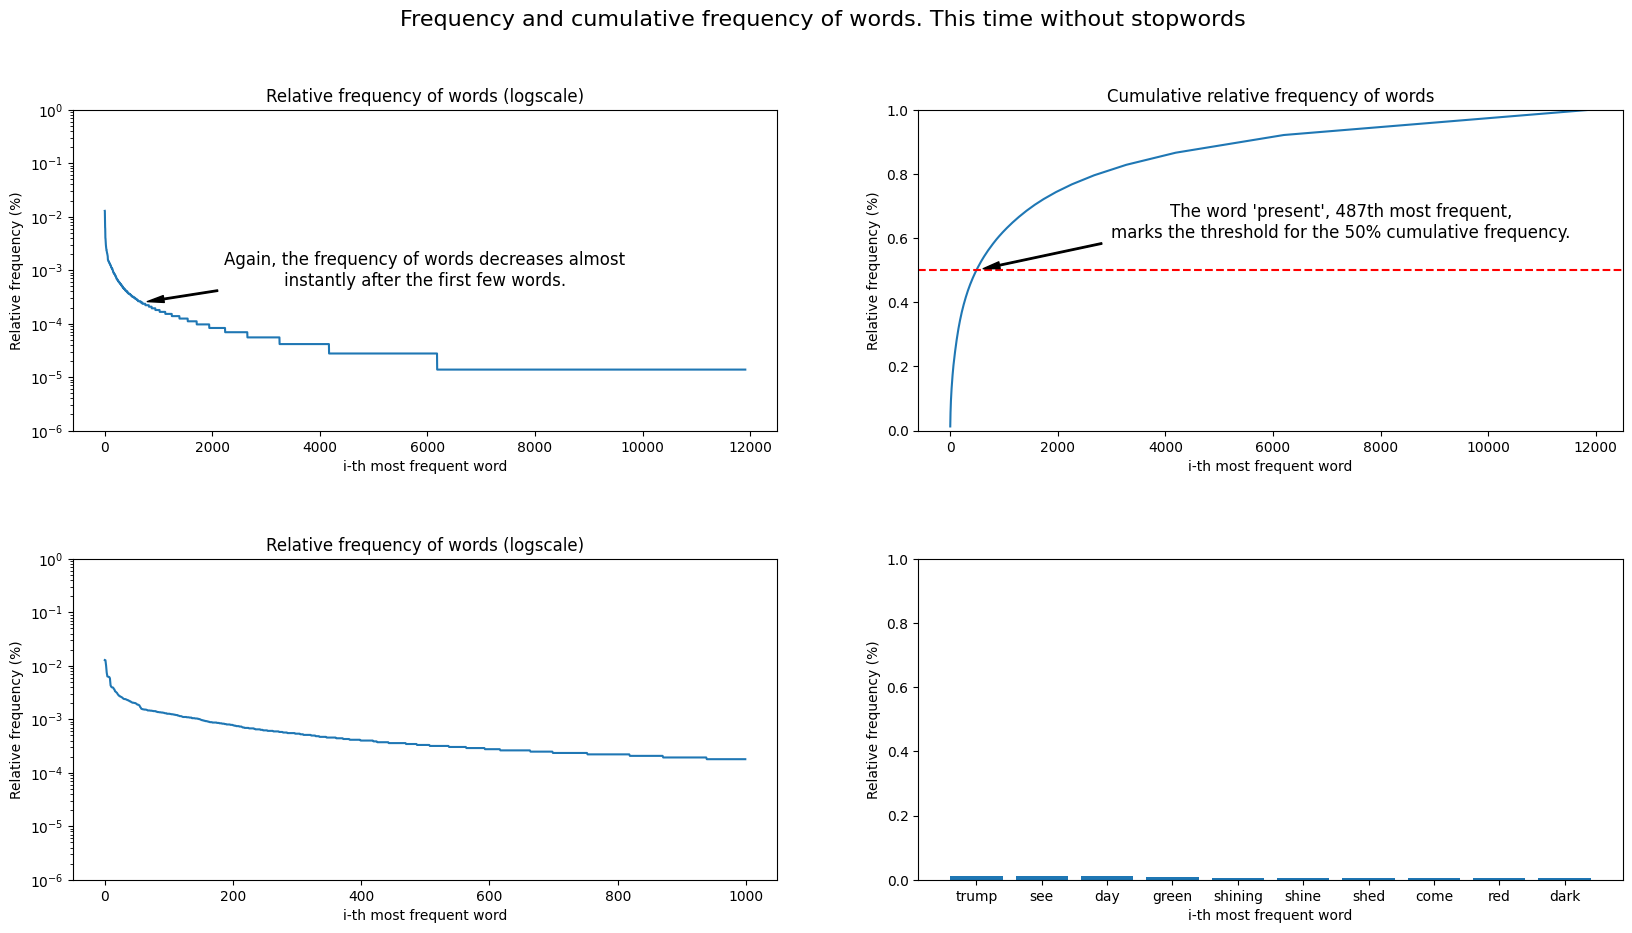

In [170]:
words = df_nonstop["word"]

# sort by frequency
counts = words.value_counts()
counts = counts.sort_values(ascending=False)

# plot values in a line
frequency = counts.values
relative_frequency = frequency / frequency.sum()

# find the position of the first value with the cummulative frequency > 0.5
half_x = (relative_frequency.cumsum() > 0.5).argmax()
word_half_x = counts.index[half_x]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4)
for i, row in enumerate(ax):
    for j, col in enumerate(row):
        # defaults
        col.set_ylim(0, 1)
        col.set_xlabel("i-th most frequent word")
        col.set_ylabel("Relative frequency (%)")
        if i == 0:
            if j == 0:
                col.set_yscale("log")
                col.plot(relative_frequency)
                # change ylim to show the plot better
                col.set_ylim(1e-6, 1)
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
                col.annotate(
                    "Again, the frequency of words decreases almost\ninstantly after the first few words.",
                    xy=(0.1, 0.4),
                    xytext=(0.5, 0.5),
                    # the text 
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                    xycoords="axes fraction",
                )
            else:
                col.plot(relative_frequency.cumsum())
                col.set_title("Cumulative relative frequency of words")
                # show the x-value where the y value is 0.5
                col.axhline(y=0.5, color="r", linestyle="--")
                col.annotate(
                    f"The word '{word_half_x}', {half_x}th most frequent,\nmarks the threshold for the 50% cumulative frequency.",
                    xycoords="data",
                    textcoords="axes fraction",
                    xy=(half_x, 0.5),
                    xytext=(0.6, 0.65),
                    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=5),
                    horizontalalignment="center",
                    verticalalignment="center",
                    fontsize=12,
                )
        else:
            #col.set_xticks(range(1000))
            #col.set_xticklabels(counts.index[:1000])
            if j == 0:
                col.set_yscale("log")
                col.plot(relative_frequency[:1000])
                # change ylim to show the plot better
                col.set_ylim(1e-6, 1)
                col.set_yscale("log")
                col.set_title("Relative frequency of words (logscale)")
            else:
                # show bar chart of the top 10 words
                col.bar(counts.index[:10], relative_frequency[:10])

# Title
fig.suptitle("Frequency and cumulative frequency of words. This time without stopwords", fontsize=16)

    

## Let's see how much the dataset has changed

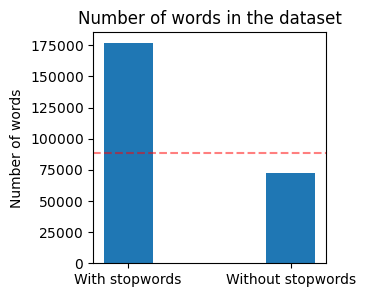

In [196]:
# plot the difference in number of words between the two datasets
fig, ax = plt.subplots(figsize=(3, 3))
ax.bar(["With stopwords", "Without stopwords"], [len(df), len(df_nonstop)], width=0.3)
# the yticks in scientific notation
ax.ticklabel_format(style="sci", axis="y", useMathText=True)
ax.set_title("Number of words in the dataset")
ax.set_ylabel("Number of words")

# h-line in the middle
ax.axhline(y=len(df) / 2, color="r", linestyle="--", alpha=0.5)
